<font size=10>**Mid-term Project**</font>

<font size=6>**Your AI Email Secretary**</font>

# **Business Problem - Automating Email Prioritization & Responses**



**Alex Carter**, a seasoned **Senior Manager in Software Development** at **Orion Tech Solutions**, plays a pivotal role in ensuring the smooth execution of multiple IT projects. Orion Tech Solutions, a **mid-sized IT services company**, prides itself on delivering cutting-edge software solutions to global clients, balancing innovation with operational efficiency.

With years of experience in software engineering and project management, Alex’s day is a mix of **strategic planning, problem-solving, and stakeholder coordination**. Managing a diverse portfolio of projects, Alex works closely with **internal teams, vendors, and clients**, ensuring deliverables meet expectations while navigating technical and organizational challenges.


**The Challenge**

A high-profile client has recently entrusted Orion Tech Solutions with the development of a **next-generation cloud security platform**. While the project holds immense potential for growth and recognition, it also brings **complexity, tight deadlines, and high stakeholder expectations**.

As the project nears critical milestones, Alex faces **multiple challenges:**

* Ensuring **timely delivery** while balancing **resource constraints**.
* Managing **escalations** related to security vulnerabilities discovered during testing.
* Communicating with **clients, vendors, and internal teams** to align expectations.
* Handling **unexpected system downtimes** due to scheduled IT maintenance.
* Addressing **compliance concerns** raised by the legal team on certain third-party integrations.

With multiple stakeholders relying on Alex’s leadership, **clear and effective communication** is essential. Every email, meeting, and decision made plays a role in determining the project's success.

### **The Case Study**
This case study explores the **real-world challenges** Alex encounters, highlighting how well-structured communication can help in:
1. **Crisis Management** – Handling security breaches and system outages.
2. **Client Relations** – Effectively communicating progress and addressing feedback.
3. **Team Coordination** – Ensuring alignment between development, security, and operations teams.
4. **Strategic Decision-Making** – Navigating legal, financial, and technical roadblocks.

Through **realistic scenarios and email exchanges**, we will examine how Alex can **leverage professional communication strategies** to tackle these challenges head-on, ensuring **project success and business continuity**.

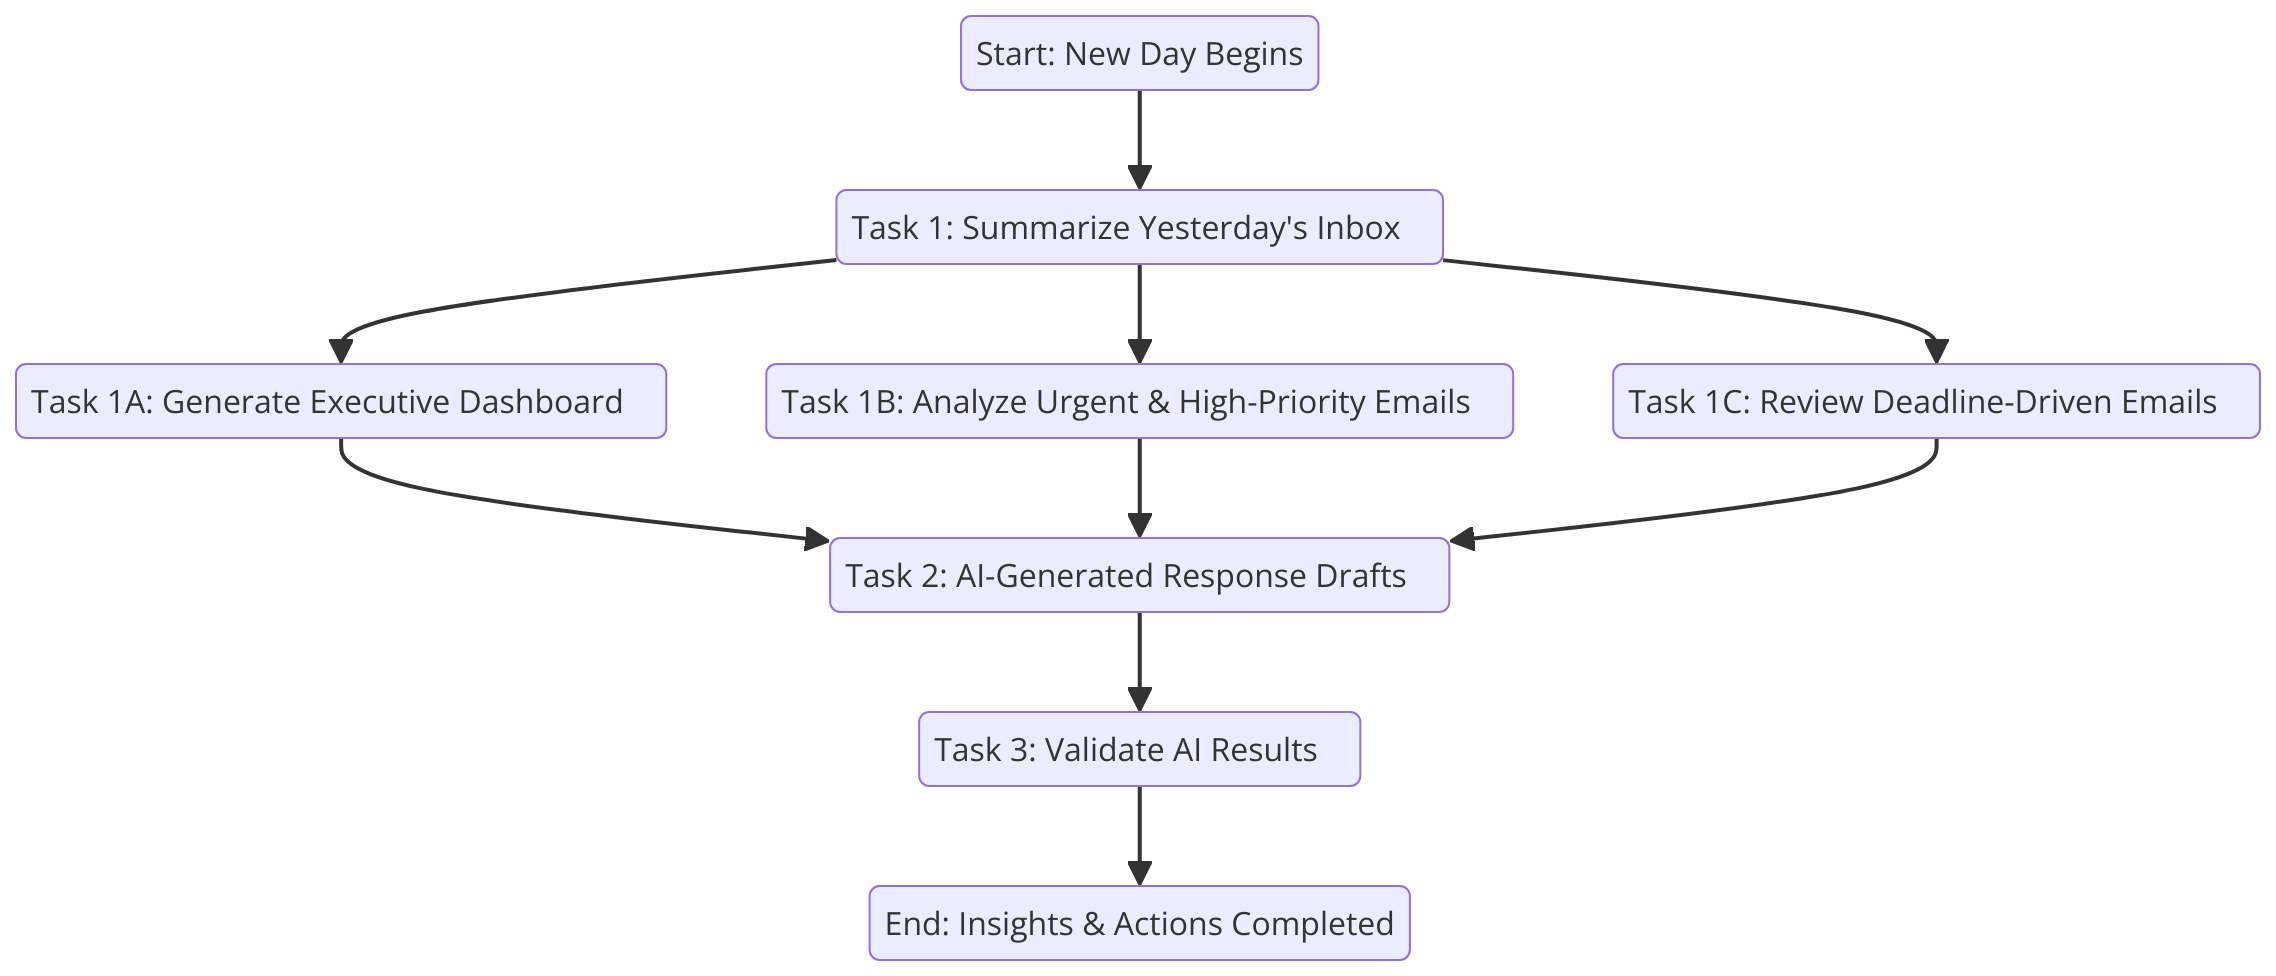

### **Objective**

The goal of this project is to create a Generative AI-powered system that:
1. **Summarize** yesterday’s emails into actionable insights. [Yesterbox Approach]
2. **Prioritizes** emails based on urgency, sender, and context.
3. **Drafts** context-aware responses, reducing manual effort.



# **LLM Setup**



In [1]:
!pip install -q openai==1.61.1

- The `config.json` file should contain **API_KEY** and **API Base URL** provided by OpenAI.
- You need to insert your actual API keys and endpoint URL obtained from your Olympus account. Refer to the **OpenAI Access Token documentation** for more information on how to generate and manage your API keys.
- This code reads the `config.json` file and extracts the API details.
  - The `API_KEY` is a **unique secret key** that authorizes your requests to OpenAI's API.
  - The `OPENAI_API_BASE` is the **API Base URL** where the model will process your requests.

**What To Do?**
- Use the sample `config.json` file provided.
- Add their **OpenAI API Key** and **Base URL** to the file.
- The `config.json` should look like this:

  ```
  {
        "API_KEY": "your_openai_api_key_here",
        "OPENAI_API_BASE": "https://your_openai_api_base/v1"
      }
  ```

In [2]:
# @title Loading the `config.json` file
import json

# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    API_KEY = config.get("API_KEY") # Loading the API Key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [3]:
model_name = "gpt-4o-mini"

- The API key and base URL are stored in environment variables to avoid hardcoding sensitive information in the code.
- The `OpenAI()` object helps us interact with the model for prompt generation.


In [4]:
from openai import AzureOpenAI
import os

# Storing API credentials in environment variables
os.environ['OPENAI_API_VERSION'] = "2024-12-01-preview"
os.environ['AZURE_OPENAI_API_KEY'] = API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = OPENAI_API_BASE

# Initialize OpenAI client
client = AzureOpenAI()

- This function helps **interact with the AI model** using two prompts:
  - **System Prompt:** Provides **background instructions** to the model on how to behave.
  - **User Prompt:** Contains the **user's query or task**.
- The `client.chat.completions.create()` method sends the request to the GPT model.
- The *temperature=0* setting ensures the response is **deterministic and consistent**.
- If any error occurs, the function will **print the error message**.


In [5]:
# @title LLM function
# @markdown Once the API details are filled, the notebook will automatically load the configuration, and learners can generate model outputs using the llm() function.


def llm(system_prompt, user_prompt):
  try:
      # Craft the messages to pass to chat.completions.create
      prompt = [
          {'role':'system', 'content': system_prompt},
          {'role': 'user', 'content': user_prompt}
      ]

      response = client.chat.completions.create(
          model=model_name,
          messages=prompt,
          temperature=0
      )

      return response.choices[0].message.content.strip()

  except Exception as e:
      prediction = f'Sorry, I encountered the following error: \n {e}'
      print(prediction)

# **Data Setup**


### **Background**

**Name**: Alex Carter  
**Company**: Orion Tech Solutions (A mid-sized IT services company)  
**Role**: Senior Manager, Software Developement  

#### **About You**  
Alex oversees multiple projects related to software development and IT infrastructure. Your role involves coordinating with stakeholders, ensuring timely delivery, handling escalations, and approving critical project-related decisions. You work with internal teams, vendors, and clients, making communication a crucial part of your job.


**Objective:** Load the dataset containing email records and apply the Yesterbox approach to filter emails received on the previous day.

In [6]:
# @title Step 1: Load the Dataset
# Data Loading

import pandas as pd
df = pd.read_csv("Alex_emails_march_04-1.csv", index_col="email_id", encoding='latin-1')      #Add the data file location
df

c:\Users\Pheon\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,date_received,sender,subject,body,main_recipient
email_id,,,,,
1,3/3/2025,Julia Martin,Approval Request: Budget Approval Needed by EOD,"Hi Alex,\n\nI hope you're doing well. As we ap...",Alex
2,3/3/2025,Fiona White,Are Your APIs Secure? Reddit & Discord Sound t...,"Hi Alex,\n\nA heated Discord discussion in the...",Alex
3,3/3/2025,Samantha Lee,Approval Needed: Project Scope Adjustment for ...,"Hi Alex,\n\nWeve encountered an unexpected AP...",Alex
4,3/3/2025,James Patel,Subject: Daily Update  Project Titan (March 3),"Hey Alex,\n\nQuick update on Project Titan for...",Alex
5,3/3/2025,David Whitmore,[URGENT] Dashboard Syncing Issues  Production...,"Hey Alex,\n\nWeve got a big issue right nowl...",Alex
6,3/3/2025,Lisa Taylor,Quick Check-In  Frontend Updates,"Hi Alex,\n\nProgress today:\n\n1. Wrapped up U...",Alex
7,3/3/2025,Nathan Cole,Approval Request: Additional AWS Resources for...,"Hi Alex,\n\nAs we scale up Project Orion, our ...",Alex
8,3/3/2025,David Kurien,Blocking Issue Alert  Client Data Sync Failing,"Hi Alex,\n\nWeve got a major problemclient t...",Alex
9,3/3/2025,Mark Swarlos,Daily Update  API Migration (March 3),"CC: Tom Richardson (QA Lead), Orion Dev Team\n...",Alex


In [7]:
# @title Step 2: Apply Yesterbox Filtering
# @markdown The Yesterbox approach involves processing emails from the previous day first before tackling today's emails.

# @markdown For this dataset, consider today's date as 4th March 2025.

# @markdown We filter the dataset to only include emails received on 3rd March 2025 (yesterday)
# (Yesterbox Approach)(Today: 4 march)



from datetime import datetime, timedelta

yesterday_date = pd.to_datetime("3/3/2025").strftime('%m/%d/%Y')

df['date_received'] = pd.to_datetime(df['date_received']).dt.strftime('%m/%d/%Y')

yesterday_emails = df[df['date_received'] == yesterday_date].reset_index(drop=True)
print(f"Filtered Emails Count: {len(yesterday_emails)}")


Filtered Emails Count: 51


In [8]:
df.shape

(60, 5)

In [9]:
yesterday_emails.shape              # Index starts from 0

(51, 5)

# **Task 1: Awareness of your email: Get to know the detailed summary of your email received**


## **1A. Executive Dashboard (Top-Level Summary of Yesterday’s Inbox)**

**Note:** Follow the instructions carefully and complete the missing sections.

Alex’s inbox is a **delicate balance of urgent action items, strategic decisions, and routine updates**. He must **prioritize effectively**—focusing on high-impact emails first, ensuring compliance with deadlines, and delegating less critical tasks to his team.

In this step, you will generate a high-level summary of the emails received using the AI Email Secretary. The AI will categorize emails into distinct categories and generate actionable insights.

**Question:**
Write the `system_prompt` that will guide the AI model to generate an executive summary based on the dataset. The prompt should:

1. Categorize emails into six distinct categories.
  - Urgent & High-Priority Emails (Requires Immediate Action)
  - Deadline-Driven Emails (Deadline is Today or meeting setups)
  - Routine Updates (Review & Acknowledge)
  - Non-Urgent Informational Emails (Deferred or Delegated)
  - Personal & Social Emails
  - Spam/Unimportant Emails

2. Count the number of emails per category.

3. Provide a final AI summary that highlights the number of critical emails requiring immediate action.

In [10]:
# @title  System Prompt

# Write your system prompt here
system_prompt = """

You are an AI that analyzes emails received in an user's inbox yesterday and classifies them into six distinct categories based on the urgency of the email. The categories are as follows:
    1. Urgent & High-Priority Emails (Requires Immediate Action)
    2. Deadline-Driven Emails (Deadline is Today or meeting setups)
    3. Routine Updates & Check-ins (Review & Acknowledge)
    4. Non-Urgent Informational Emails (Deferred or Delegated)
    5. Personal & Social Emails
    6. Spam/Unimportant Emails

For each category, count the number of emails in each category and display their value

Finally, provide a final summary that highlights the number of critical emails requiring immediate action. Below is an example output:
Total Emails from Yesterday: 100
    - 🛑 Urgent & High-Priority Emails: 10 (Require Immediate Action Today)
    - ⚡ Deadline-Driven Emails: 8 (Must Be Addressed Today)
    - 📌 Routine Updates & Check-ins: 35 (Review & Acknowledge)
    - 📎 Non-Urgent & Informational Emails: 45 (Can Be Deferred or Delegated)
    - 🎉 Personal & Social Emails: 22 (Optional Review)
    - 🗑️ Spam/Unimportant Emails Filtered Out: 20

AI Summary:
"You have 18 critical emails from yesterday that require action today (10 Urgent & High Priority and 8 Deadline-Driven). Additionally, there are 35 updates to review at your convenience."
"""

**Question:**
Construct the `user_prompt` that will pass the filtered dataset (`yesterday_emails`) to the AI model and request a structured executive summary.


In [11]:
# @title  User Prompt

# Write your user prompt here
user_prompt = f"""
Below is the attached DataFrame, which contains all the emails from yesterday that need to be analysed and categorized:
```
{yesterday_emails.to_string()}
```

"""


In [12]:
# @title  Calling the model and display the summary

response_1 = llm(system_prompt, user_prompt)        # llm is the model using gpt-4o-mini
response_1

from IPython.display import display, Markdown
display(Markdown(response_1))

Total Emails from Yesterday: 51
- 🛑 Urgent & High-Priority Emails: 15 (Require Immediate Action Today)
- ⚡ Deadline-Driven Emails: 8 (Must Be Addressed Today)
- 📌 Routine Updates & Check-ins: 10 (Review & Acknowledge)
- 📎 Non-Urgent & Informational Emails: 10 (Can Be Deferred or Delegated)
- 🎉 Personal & Social Emails: 5 (Optional Review)
- 🗑️ Spam/Unimportant Emails Filtered Out: 3

AI Summary:
"You have 23 critical emails from yesterday that require action today (15 Urgent & High Priority and 8 Deadline-Driven). Additionally, there are 10 updates to review at your convenience."

**Sample Output Example:**

A structured summary with the number of emails in each category and key action points.

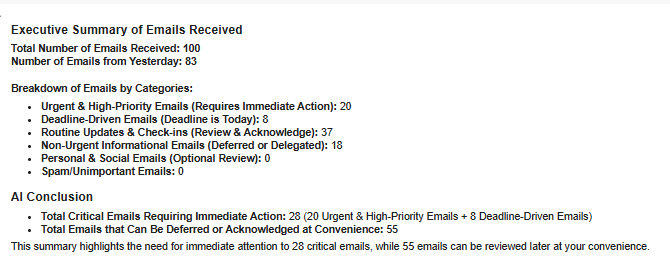

In [13]:
# @title Code to add categories to the dataset
categories = ['Urgent & High-Priority Emails',
              'Deadline-Driven Emails',
              'Routine Updates & Check-ins',
              'Non-Urgent Informational Emails',
              'Personal & Social Emails',
              'Spam/Unimportant Emails']

In [14]:
# sample of dataframe before adding the categories.
yesterday_emails.head()

,date_received,sender,subject,body,main_recipient
0,03/03/2025,Julia Martin,Approval Request: Budget Approval Needed by EOD,"Hi Alex,\n\nI hope you're doing well. As we ap...",Alex
1,03/03/2025,Fiona White,Are Your APIs Secure? Reddit & Discord Sound t...,"Hi Alex,\n\nA heated Discord discussion in the...",Alex
2,03/03/2025,Samantha Lee,Approval Needed: Project Scope Adjustment for ...,"Hi Alex,\n\nWeve encountered an unexpected AP...",Alex
3,03/03/2025,James Patel,Subject: Daily Update  Project Titan (March 3),"Hey Alex,\n\nQuick update on Project Titan for...",Alex
4,03/03/2025,David Whitmore,[URGENT] Dashboard Syncing Issues  Production...,"Hey Alex,\n\nWeve got a big issue right nowl...",Alex


In [15]:
# @title Categorizing the emails
from tqdm import tqdm  # Import the tqdm library for the progress bar

system_prompt = """

You are an AI that analyzes emails received in an user's inbox yesterday and classifies them into six distinct categories based on the urgency of the email. The categories are as follows:
    1. Urgent & High-Priority Emails (Requires Immediate Action)
    2. Deadline-Driven Emails (Deadline is Today or meeting setups)
    3. Routine Updates & Check-ins (Review & Acknowledge)
    4. Non-Urgent Informational Emails (Deferred or Delegated)
    5. Personal & Social Emails
    6. Spam/Unimportant Emails

For each email, return only the category the email belongs to. Below are some example outputs:
Example 1:
Spam/Unimportant Emails

Example 2:
Non-Urgent Informational Emails

Example 3:
Deadline-Driven Emails

Example 4:
Urgent & High-Priority Emails

Example 5:
Routine Updates & Check-ins

Example 6:
Personal & Social Emails
"""

user_prompt = f"""
"""


# Ensure the 'category' column exists in the DataFrame
if 'category' not in yesterday_emails.columns:
  yesterday_emails['category'] = None  # Create the column if it does not exist


for index, row in tqdm(yesterday_emails.iterrows(), total=df.shape[0], desc='Processing emails'):
  prompt = f"""{user_prompt}
    Please find the attached email below from yesterday that need to be analyzed:
    ```
    {row.to_string()}
    ```
  """

  category_by_llm = llm(system_prompt, prompt)

  # Append the category generated by the LLM to the 'category' column in the same row
  if category_by_llm in categories:
    yesterday_emails.at[index, 'category'] = category_by_llm
  else:
    print(category_by_llm)
    yesterday_emails.at[index, 'category'] = ""

Processing emails:  85%|████████▌ | 51/60 [00:20<00:03,  2.47it/s]


In [16]:
# @title Display the updated DataFrame
yesterday_emails.head()

,date_received,sender,subject,body,main_recipient,category
0,03/03/2025,Julia Martin,Approval Request: Budget Approval Needed by EOD,"Hi Alex,\n\nI hope you're doing well. As we ap...",Alex,Deadline-Driven Emails
1,03/03/2025,Fiona White,Are Your APIs Secure? Reddit & Discord Sound t...,"Hi Alex,\n\nA heated Discord discussion in the...",Alex,Non-Urgent Informational Emails
2,03/03/2025,Samantha Lee,Approval Needed: Project Scope Adjustment for ...,"Hi Alex,\n\nWeve encountered an unexpected AP...",Alex,Urgent & High-Priority Emails
3,03/03/2025,James Patel,Subject: Daily Update  Project Titan (March 3),"Hey Alex,\n\nQuick update on Project Titan for...",Alex,Routine Updates & Check-ins
4,03/03/2025,David Whitmore,[URGENT] Dashboard Syncing Issues  Production...,"Hey Alex,\n\nWeve got a big issue right nowl...",Alex,Urgent & High-Priority Emails


In [17]:
yesterday_emails.category.value_counts()

category
Urgent & High-Priority Emails      19
Routine Updates & Check-ins        15
Deadline-Driven Emails              8
Non-Urgent Informational Emails     5
Spam/Unimportant Emails             3
Personal & Social Emails            1
Name: count, dtype: int64

## **1B. Urgent Emails from Yesterday (🛑 Must-Do First Today)**

**Note:** Follow the instructions carefully and complete the missing sections.

**Urgent & High-Priority Emails (Requires Immediate Action)**

**Examples**
- **Subject: Security Breach Alert - Immediate Response Needed**

  **From:** Diana Wilson (Cybersecurity Lead)

  *Summary:* A critical security vulnerability was discovered in the production environment. Immediate action is required to prevent potential data leaks.

- **Subject: Compliance Issue - Legal Review Needed by EOD**

  **From:** Fiona White (Legal Counsel)

  *Summary:* A third-party software integration has raised compliance concerns. Legal review must be completed today to avoid project delays.

- **Subject: Client Escalation - API Downtime Impacting Operations**

  **From:** Michael Brown (Account Manager)

  *Summary:* A major client has reported API failures affecting their workflow. A resolution and immediate communication are needed.

**Question:**
Write the `system_prompt` that will guide the AI to extract all urgent and high-priority emails from the dataset.

Ensure each email summary follows this format:
  - Subject:
  - Received:
  - Sender Name:
  - Summary:
  - Next Step: (it should be particular to that email)

In [18]:
# @title  System Prompt

# Write your system prompt here
system_prompt = """
You are an AI that analyzes Urgent & High Priority Emails from yesterday and summarizes their contents to be more easily readable by an individual. 
Each summary output should have 5 components: 
    - Subject of the email
    - The date the email was received
    - Name of the sender of the email
    - A brief summary of the email contents
    - What next step should be taken by the recipient of that particular email.
Below is an example output for an inbox containing 3 Urgent & High-Priority emails:
Here are the 3 Urgent and High-Priority emails that require your attention or intervention, as per the provided records. All emails listed were received yesterday and are part of today's to-do list.

Subject: Security Breach Alert - Immediate Response Needed
Received: 03/03/25
From: Diana Wilson
Summary: A critical security vulnerability was discovered in the production environment. Immediate action is required to prevent potential data leaks.
Next Steps: Review the details of the security breach and respond with your thoughts

Subject: Compliance Issue - Legal Review Needed by EOD
Received: 03/03/25
From: Fiona White
Summary: A third-party software integration has raised compliance concerns. Legal review must be completed today to avoid project delays.
Next Steps: Review the compliance issues and provide your feedback by EOD 

Subject: Client Escalation - API Downtime Impacting Operations
Received: 03/03/25
From: Michael Brown
Summary: A major client has reported API failures affecting their workflow. A resolution and immediate communication are needed.
Next Steps: Investigate the API downtime issues and find a resolution, then respond to michael with the solution.
"""


**Question:**
Construct the `user_prompt` that will pass the filtered dataset to the AI model for identifying urgent emails.

In [19]:
# @title  User Prompt

# You may format the classifying method according to you
urgent_emails = yesterday_emails[yesterday_emails['category'] == 'Urgent & High-Priority Emails']

# Write your user prompt here
user_prompt = f"""
Below is the attached DataFrame, which contains the Urgent & High-Priority Emails that need to be analysed and summarized:
```
{urgent_emails.to_string()}
```
"""

In [20]:
# @title  Calling the model and display the summary

response_2 = llm(system_prompt, user_prompt)

from IPython.display import display, Markdown
display(Markdown(response_2))


Here are the 20 Urgent and High-Priority emails that require your attention or intervention, as per the provided records. All emails listed were received yesterday and are part of today's to-do list.

---

**Subject:** Approval Needed: Project Scope Adjustment for Acme Corp Integration  
**Received:** 03/03/2025  
**From:** Samantha Lee  
**Summary:** A proposed adjustment to the integration approach with Acme Corp due to an API limitation. The new plan involves using a message queue to maintain performance without delaying the project timeline.  
**Next Steps:** Confirm if the adjustment can proceed or request a discussion.

---

**Subject:** [URGENT] Dashboard Syncing Issues – Production Metrics Missing  
**Received:** 03/03/2025  
**From:** David Whitmore  
**Summary:** Live production metrics are not syncing on the Orion Analytics Dashboard, causing data gaps. Immediate confirmation is needed to identify if it's an API issue or data processing lag.  
**Next Steps:** Investigate the syncing issues and provide an update within 24 hours.

---

**Subject:** Approval Request: Additional AWS Resources for Project Orion  
**Received:** 03/03/2025  
**From:** Nathan Cole  
**Summary:** Request for approval to provision additional AWS resources as current usage has hit 90% capacity, which is causing performance bottlenecks.  
**Next Steps:** Approve the additional resources by March 7 to avoid service degradation.

---

**Subject:** Blocking Issue Alert – Client Data Sync Failing  
**Received:** 03/03/2025  
**From:** David Kurien  
**Summary:** Client transaction data is failing to sync for 20% of requests, likely due to a recent deployment. An action plan is needed urgently.  
**Next Steps:** Determine whether to roll back the deployment or isolate the root cause.

---

**Subject:** URGENT: Approval Needed for 2-Week Extension on Acme Corp Deployment  
**Received:** 03/03/2025  
**From:** Tanya Patel  
**Summary:** Request for a two-week extension on the Acme Corp deployment due to internal team conflicts that caused delays.  
**Next Steps:** Decide on the extension request and communicate the decision.

---

**Subject:** System Crashing During Shift Changes – URGENT  
**Received:** 03/03/2025  
**From:** David Whitmore  
**Summary:** The Orion Manufacturing System is crashing during shift changes, preventing operators from logging in. Immediate assistance is required.  
**Next Steps:** Join the scheduled call at 3 PM EST to discuss the issue.

---

**Subject:** ?? Security Risk – Critical Patch Delayed  
**Received:** 03/03/2025  
**From:** Bob Smith  
**Summary:** A critical security patch rollout is delayed due to dependency conflicts, exposing the system to vulnerabilities.  
**Next Steps:** Decide whether to push the patch with risks or delay further.

---

**Subject:** URGENT: Production Halt – Machine Control System Unresponsive  
**Received:** 03/03/2025  
**From:** David Whitmore  
**Summary:** The Orion Machine Control System is unresponsive, halting production. Immediate attention is required.  
**Next Steps:** Call David immediately to address the issue.

---

**Subject:** [High Priority] Authentication Failing for Multiple Users  
**Received:** 03/03/2025  
**From:** Mark Davidson  
**Summary:** Multiple engineers are unable to log in to the security monitoring platform due to an authentication issue.  
**Next Steps:** Investigate the authentication problem and restore access as soon as possible.

---

**Subject:** Approval Needed: Purchase of Design Tool for Engineering Team  
**Received:** 03/03/2025  
**From:** Liam Ross  
**Summary:** Request for approval to purchase 20 licenses for Adobe Creative Cloud for the engineering team, with concerns about cost-effectiveness.  
**Next Steps:** Decide on the approval or explore alternative options.

---

**Subject:** URGENT: Approval for Security Audit Vendor – Time-Sensitive  
**Received:** 03/03/2025  
**From:** Rachel Lim  
**Summary:** Urgent approval needed for a security audit contract with CyberShield, which is required for compliance.  
**Next Steps:** Confirm approval by March 7 to avoid compliance issues.

---

**Subject:** URGENT: Critical System Downtime – Immediate Attention Required  
**Received:** 03/03/2025  
**From:** David Whitmore  
**Summary:** Major outage with the Orion Analytics Dashboard affecting production data access. Immediate resolution is required.  
**Next Steps:** Provide a status update within the next hour or escalate to the engineering team.

---

**Subject:** Follow-Up: Server Downtime - Critical Fix Required  
**Received:** 03/03/2025  
**From:** Bob Smith  
**Summary:** Unexpected server downtime is impacting critical services, and additional input is needed to expedite the fix.  
**Next Steps:** Review the attached logs and respond promptly.

---

**Subject:** Approval Request: Dev Environment Upgrade for Faster Builds  
**Received:** 03/03/2025  
**From:** Kevin Tran  
**Summary:** Request for approval to upgrade cloud servers to improve build times in the development environment.  
**Next Steps:** Approve the upgrade to proceed by March 10.

---

**Subject:** URGENT: Overdue Invoice Approval for Cloud Services  
**Received:** 03/03/2025  
**From:** Sarah Mitchell  
**Summary:** An overdue invoice for cloud security monitoring needs immediate approval to avoid late fees and service disruption.  
**Next Steps:** Approve the invoice as soon as possible.

---

**Subject:** Firewall Logs Disappeared – What’s Going On?  
**Received:** 03/03/2025  
**From:** Mark Davidson  
**Summary:** Missing firewall logs from February are a major concern for audit compliance.  
**Next Steps:** Investigate the issue and provide a resolution.

---

**Subject:** URGENT: Medication Alerts Not Firing – This is Dangerous  
**Received:** 03/03/2025  
**From:** Rachel Thompson  
**Summary:** Automated medication alerts for ICU patients are not functioning, posing a patient safety risk.  
**Next Steps:** Join the emergency call scheduled in 30 minutes to address the issue.

---

**Subject:** Approval Request: Travel Budget for AWS Summit 2025  
**Received:** 03/03/2025  
**From:** Olivia Chen  
**Summary:** Request for approval for travel expenses for two team members to attend the AWS Summit 2025 for training.  
**Next Steps:** Confirm if the travel budget can be approved.

---

**Subject:** Urgent: Performance Degradation in Production System  
**Received:** 03/03/2025  
**From:** Nathan Ellis  
**Summary:** Critical slowdown in the production environment affecting client-side API calls due to high CPU utilization.  
**Next Steps:** Approve an emergency scale-up of the database instance and decide on client communication.

--- 

Please prioritize these emails based on their urgency and take the necessary actions as outlined.

**Sample Output Example:**

A list of urgent emails with detailed summaries and next steps.

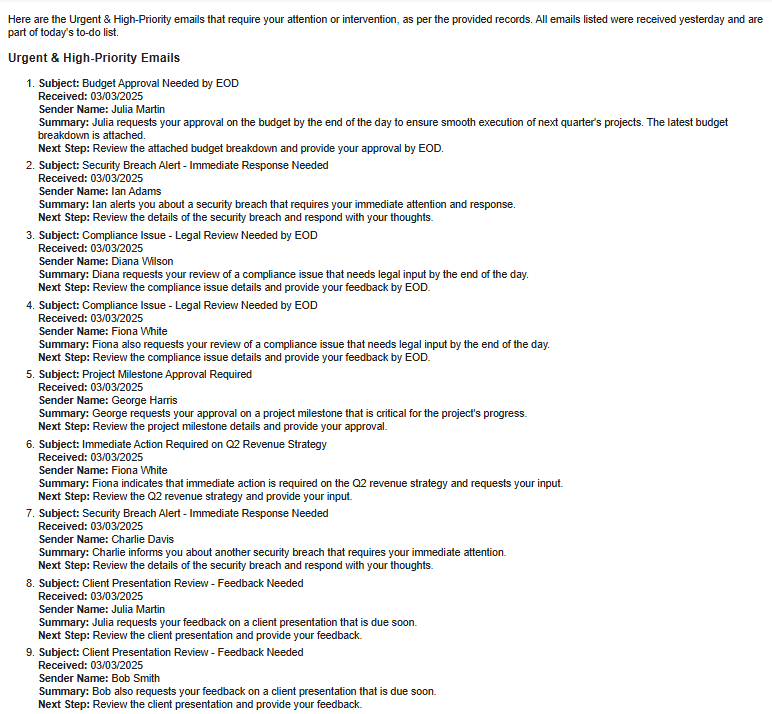

## **1C: Deadline-Driven Emails from Yesterday (⚡ Needs Attention Today)**

**Note:** Follow the instructions carefully and complete the missing sections.

**Deadline-Driven Emails (Needs to be Addressed Today)**

**Examples**

- **Subject: Q2 Revenue Strategy - Immediate Action Required**
  
  **From:** George Harris (Director of Strategy)
  
  *Summary:* Leadership expects a finalized strategy document by EOD to align with upcoming board discussions.

- **Subject: Client Presentation Review - Feedback Needed**
  
  **From:** George Harris (Senior Sales Executive)
  
  *Summary:* Feedback is required on a key client pitch deck before the presentation scheduled for tomorrow.

- **Subject: Employee Engagement Survey Reminder**
  
  **From**: Charlie Davis (HR Manager)
  
  *Summary:* Employees must complete the engagement survey before the end of the day to finalize workplace improvement initiatives.

**Question:**
Write the `system_prompt` that will guide the AI model to extract deadline-driven emails. The summary should include:
  - Subject:
  - Received:
  - Sender Name:
  - Summary:
  - Next Step: (it should be particular to that email)


In [21]:
# @title  System Prompt

# Write your system prompt here
system_prompt = """
You are an AI that analyzes Deadline-Driven Emails that needs to be addressed today and summarizes their contents to be more easily readable by an individual. 
Each summary output should have 5 components: 
    - Subject of the email
    - The date the email was received
    - Name of the sender of the email
    - A brief summary of the email contents
    - What next step should be taken by the recipient of that particular email.
Below is an example output for an inbox containing 3 Deadline-Driven Emails:
Here are the 3 Deadline-Driven emails received yesterday that require action today, exluding those already categorized as Urgent & High-Priority

Subject: Employee Engagement Survey Reminder
Received: 03/03/25
From: Charlie Davis
Summary: Charlie reminds you to complete the Employee Engagement Survey before the deadline. Your feedback is essential in shaping company policies and improving workplace culture.
Next Steps: Complete the Employee Engagement Survey by the end of the day.

Subject: Quarterly Report Submission Deadline
Received: 02/15/25
From: Bob Smith
Summary: Bob reminds you about the upcoming deadline for the quarterly report submission.
Next Steps: Prepare and submit the quarterly report by the end of the day.

Subject: Client Presentation Review - Feedback Needed
Received: 02/28/25
From: Ian Adams
Summary: Ian requests your feedback on a client presentation that is due soon.
Next Steps: review the client presentation and provide your feedback by the end of the day.
"""


**Question:**
Construct the `user_prompt` to pass the filtered dataset and request deadline-driven emails with next steps.

Ensure that:
  - These emails are separate from the Urgent & High-Priority Emails already covered.
  - **Exclude** any emails already categorized under **Urgent & High-Priority**.
  - Each email must mention a **specific deadline** for today or require action to meet a delivery timeline.
  - The final count of Deadline-Driven emails + Urgent & High-Priority emails should equal the Critical Emails count in the Executive Summary.

In [22]:
# @title  User Prompt

# You may format the classifying method according to you
deadline_emails = yesterday_emails[yesterday_emails['category'] == 'Deadline-Driven Emails']

# Write your user prompt here
user_prompt = f"""
Below is the attached DataFrame, which contains the Deadline-Driven Emails that need to be analysed and summarized:
```
{deadline_emails.to_string()}
```
"""

In [23]:
# @title  Calling the model and display the summary

response_3 = llm(system_prompt, user_prompt)

from IPython.display import display, Markdown
display(Markdown(response_3))


Here are the Deadline-Driven emails received today that require action:

Subject: Approval Request: Budget Approval Needed by EOD  
Received: 03/03/2025  
From: Julia Martin  
Summary: Julia requests your approval for the budget by the end of the day to ensure the smooth execution of next quarter's projects. She has attached the latest budget breakdown for your review.  
Next Steps: Review the attached budget breakdown and provide your approval by the end of the day.

Subject: EBR Meeting Invite – Sentinel Cyber Inc. (Microsoft Teams)  
Received: 03/03/2025  
From: Lisa Taylor  
Summary: Lisa invites you to the Executive Business Review (EBR) meeting scheduled for March 14, 2025, from 2:00 PM to 3:30 PM EST on Microsoft Teams. The agenda includes SLA performance review and AI-driven threat detection enhancements.  
Next Steps: Confirm your attendance for the EBR meeting on March 14, 2025.

Subject: Scheduling Q1 Executive Business Review (EBR) – Sentinel Cyber Inc.  
Received: 03/03/2025  
From: Alex Carter  
Summary: Alex proposes dates for the Quarterly Executive Business Review (EBR) with your team, suggesting March 12 or March 14, 2025. Key discussion points include security threat landscape and performance review.  
Next Steps: Choose a preferred date for the EBR and respond to Alex.

Subject: EBR Meeting Invite – Acme Manufacturing (Google Meet)  
Received: 03/03/2025  
From: Ethan Brown  
Summary: Ethan invites you to the EBR meeting on March 18, 2025, from 3:00 PM to 4:30 PM CST on Google Meet. The agenda includes ERP system performance and security updates.  
Next Steps: Confirm your attendance for the EBR meeting on March 18, 2025.

Subject: Escalation – Valve Healthcare (Zoom)  
Received: 03/03/2025  
From: Julia Martin  
Summary: Julia informs you about an escalation meeting regarding ERP system downtime affecting production, scheduled for March 6, 2025, from 11:00 AM to 12:00 PM CST on Microsoft Teams.  
Next Steps: Prepare for the escalation meeting on March 6, 2025.

Subject: RE: Scheduling Q1 Executive Business Review (EBR) – Acme Manufacturing  
Received: 03/03/2025  
From: Daniel Goodpacker  
Summary: Daniel confirms the EBR meeting on March 18 at 3 PM CST and suggests additional agenda items regarding supply chain visibility and system latency issues. He also requests to invite the CIO, Samantha Brooks.  
Next Steps: Acknowledge Daniel's confirmation and ensure the CIO is invited to the meeting.

Subject: Daily Stand-up – Frontend Team (Microsoft Teams)  
Received: 03/03/2025  
From: Helen Paul  
Summary: Helen reminds you of the daily stand-up meeting scheduled for March 4, 2025, from 11:00 AM to 11:15 AM EST on Microsoft Teams, addressing UI bugs reported in Valve Healthcare's mobile dashboard.  
Next Steps: Attend the daily stand-up meeting on March 4, 2025.

Subject: Pending Approval – Invoice Dispute (Microsoft Teams)  
Received: 03/03/2025  
From: Alice Johnson  
Summary: Alice discusses a pending invoice approval meeting scheduled for March 5, 2025, from 4:00 PM to 4:45 PM EST on Microsoft Teams, regarding an unresolved invoice dispute.  
Next Steps: Prepare for the invoice approval discussion on March 5, 2025.

**Sample Output Example:**

A list of deadline-driven emails with summaries and next steps.

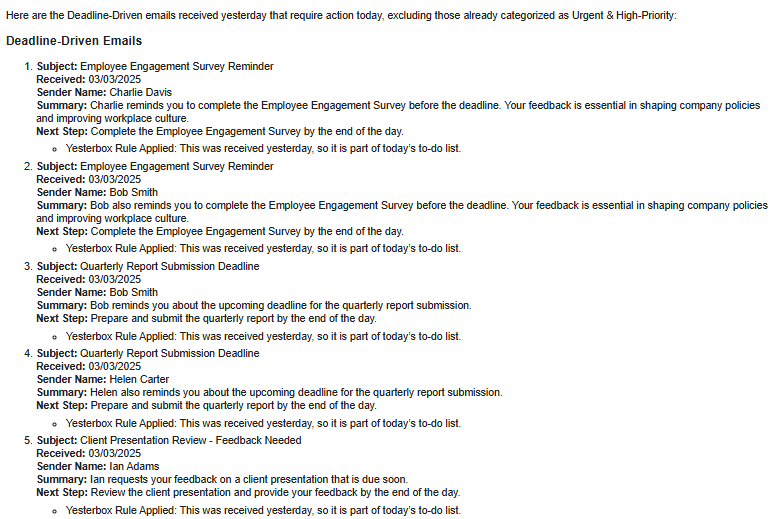

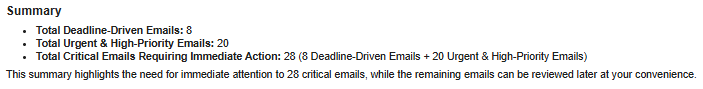

# **Task 2: AI-Generated "First Response" Drafts for High Priority Emails**

**Note:** Follow the instructions carefully and complete the missing sections.

**Objective:** Generate AI-drafted responses for critical emails received yesterday.

**Question:**
Write the `system_prompt` that will guide the AI model to generate professional email responses.

The response should:
  - Acknowledge the sender’s request and contextually relevant.
  - Address the key points, queries, or actions requested in the original email.
  - Provide a clear next step or decision.
  - Maintain a polite, formal, and professional tone, aligned with corporate communication standards.

In [24]:
# @title  System Prompt

# Write your system prompt here
system_prompt = """
You are an AI that analyzes Urgent & High Priority Emails from yesterday and drafts a first response to the email that the user can use as a template to send their email.
The first response should:
    - Acknowledge the email sender's request and be contextually relevant.
    - Address the key points, queries, or actions requested in the original email.
    - Provide a clear next step or decision that the user should make.
    - Maintain a poliute, formal, and professional tone, aligned with corporate communication standards, including a salutation and professional closing.
Below is an example output for an inbox of the user Alex containing 3 Urgent & High Priority Emails:
Here are the AI-drafted responses for the Urgent & High Priority Emails received yesterday:

Subject: Budget Approval Needed by EOD
Sender Name: Julia Martin
AI Drafted Reply: 
Dear Julia,

Thank you for your email and for providing the budget breakdown. I will review the attached document and ensure that my approval is provided by the end of the day to facilitate the smooth exectuion of next quarter's projects.

Best regards,
Alex

Subject: Security Breach Alert - Immediate Response Needed
Sender Name: Ian Adams
AI Drafted Reply:
Dear Ian,

Thank you for brining the security breach to my attention. I will review the details immediately and provide my thoughts as soon as possible.

Best regards,
Alex

Subject: Compliance Issue - Legal Review Needed by EOD
Sender Name: Diana Wilson
AI Drafted Reply:
Dear Diana,

Thank you for your email regarding the compliance issue. I will review the details and provide my feedback by the end of the day as requested.

Best regards,
Alex
"""


**Question:**
Construct the `user_prompt` to generate AI responses for all critical emails from yesterday.

In [25]:
# @title  User Prompt

# You may format the classifying method according to you
critical_emails = yesterday_emails[yesterday_emails['category'].isin(['Urgent & High-Priority Emails', 'Deadline-Driven Emails'])]

# Write your user prompt here
user_prompt = f"""
Below is the attached DataFrame, which contains Urgent & High Priority Emails that need to be analysed and have a response drafted for:
```
{critical_emails.to_string()}
```
"""

In [26]:
# @title  Calling the model and display the summary

response_4 = llm(system_prompt, user_prompt)
from IPython.display import display, Markdown
display(Markdown(response_4))

Here are the AI-drafted responses for the Urgent & High Priority Emails received yesterday:

---

**Subject: Approval Request: Budget Approval Needed by EOD**  
**Sender Name: Julia Martin**  
**AI Drafted Reply:**  
Dear Julia,

Thank you for your email regarding the budget approval. I will review the attached budget breakdown and provide my approval by the end of the day to ensure the smooth execution of next quarter's projects. If I have any concerns, I will reach out to discuss.

Best regards,  
Alex

---

**Subject: Approval Needed: Project Scope Adjustment for Acme Corp Integration**  
**Sender Name: Samantha Lee**  
**AI Drafted Reply:**  
Dear Samantha,

Thank you for bringing the API limitation and proposed adjustment to my attention. I appreciate the detailed outline of the original and proposed plans. I am in favor of proceeding with the message queue-based approach to ensure we meet our timeline. Please go ahead with the implementation.

Best regards,  
Alex

---

**Subject: [URGENT] Dashboard Syncing Issues – Production Metrics Missing**  
**Sender Name: David Whitmore**  
**AI Drafted Reply:**  
Dear David,

Thank you for alerting me to the dashboard syncing issues. I will coordinate with my team to investigate the discrepancies and determine whether this is an API issue or a data processing lag. I will provide you with an update within the next 24 hours.

Best regards,  
Alex

---

**Subject: Approval Request: Additional AWS Resources for Project Orion**  
**Sender Name: Nathan Cole**  
**AI Drafted Reply:**  
Dear Nathan,

Thank you for your email regarding the need for additional AWS resources for Project Orion. I approve the increase in EC2 instances and storage to avoid performance bottlenecks. Please proceed with the provisioning.

Best regards,  
Alex

---

**Subject: Blocking Issue Alert – Client Data Sync Failing**  
**Sender Name: David Kurien**  
**AI Drafted Reply:**  
Dear David,

Thank you for bringing this critical issue to my attention. I understand the urgency of the client transaction data sync failure. I will discuss this with my team immediately to determine whether we should roll back or isolate the root cause first. I will keep you updated on our progress.

Best regards,  
Alex

---

**Subject: URGENT: Approval Needed for 2-Week Extension on Acme Corp Deployment**  
**Sender Name: Tanya Patel**  
**AI Drafted Reply:**  
Dear Tanya,

Thank you for your email regarding the extension for the Acme Corp deployment. I understand the circumstances surrounding the delay and agree that a two-week extension is necessary to ensure quality delivery. Please proceed with the new timeline.

Best regards,  
Alex

---

**Subject: System Crashing During Shift Changes – URGENT**  
**Sender Name: David Whitmore**  
**AI Drafted Reply:**  
Dear David,

Thank you for notifying me about the system crashing during shift changes. I will have my team investigate this issue immediately. I appreciate your invitation for a call, and I will join the meeting at 3 PM EST to discuss further.

Best regards,  
Alex

---

**Subject: Security Risk – Critical Patch Delayed**  
**Sender Name: Bob Smith**  
**AI Drafted Reply:**  
Dear Bob,

Thank you for the update regarding the security patch delay. Given the potential risks involved, I recommend we proceed with the patch rollout despite the known vulnerabilities. Please keep me informed of any developments.

Best regards,  
Alex

---

**Subject: URGENT: Production Halt – Machine Control System Unresponsive**  
**Sender Name: David Whitmore**  
**AI Drafted Reply:**  
Dear David,

Thank you for bringing this critical production halt to my attention. I will prioritize this issue and have my team investigate immediately. I will join the Zoom call you scheduled to discuss the situation further.

Best regards,  
Alex

---

**Subject: URGENT: Approval for Security Audit Vendor – Time-Sensitive**  
**Sender Name: Rachel Lim**  
**AI Drafted Reply:**  
Dear Rachel,

Thank you for your follow-up regarding the security audit contract with CyberShield. I approve the contract for $25,000 to ensure compliance for our MedTech client. Please confirm with the vendor at your earliest convenience.

Best regards,  
Alex

---

**Subject: URGENT: Critical System Downtime – Immediate Attention Required**  
**Sender Name: David Whitmore**  
**AI Drafted Reply:**  
Dear David,

Thank you for alerting me to the major outage with the Orion Analytics Dashboard. I will escalate this issue to the engineering team immediately and ensure we have a resolution or workaround by the specified deadline. I will keep you updated on our progress.

Best regards,  
Alex

---

**Subject: URGENT: Overdue Invoice Approval for Cloud Services**  
**Sender Name: Sarah Mitchell**  
**AI Drafted Reply:**  
Dear Sarah,

Thank you for bringing the overdue invoice to my attention. I will prioritize the approval of the $8,500 invoice from CloudOps Solutions to avoid any late fees or service disruptions. 

Best regards,  
Alex

---

**Subject: Approval Request: Travel Budget for AWS Summit 2025**  
**Sender Name: Olivia Chen**  
**AI Drafted Reply:**  
Dear Olivia,

Thank you for your email regarding the travel budget for the AWS Summit 2025. I approve the estimated cost of $3,500 for the two team members to attend. Please proceed with the arrangements.

Best regards,  
Alex

--- 

Feel free to modify any of the responses as needed before sending them out.

**Sample Output Example:**

A list of AI-drafted resoponses for the critical emails received yesterday with detailed summaries and next steps.

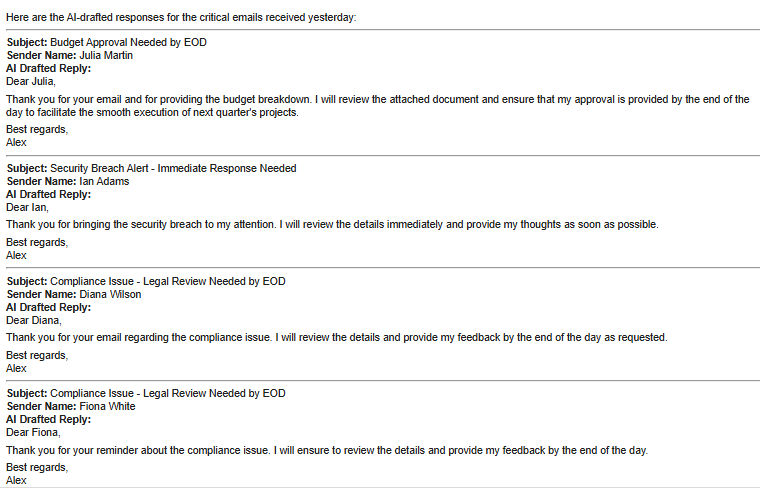

# **Task 3: Evaluation**

**Note:** Follow the instructions carefully and complete the missing sections.

## **Evaluation of Prompt Outputs with LLM-as-a-Judge**

**1. Introduction**

Evaluating the quality of prompts using LLM-as-a-Judge involves leveraging a more advanced Language Model (LLM) to assess the quality, correctness, and effectiveness of responses generated by another LLM or the same model. This method provides automated, consistent, and scalable qualitative and quantitative evaluations.

The evaluation process will:

- Use LLM-as-a-Judge to rate prompt outputs on predefined criteria.

- Automate scoring and feedback generation.

- Provide insights for prompt refinement.

Large Language Models (LLMs) can be used not only to generate content but also to **evaluate** the quality of generated responses.


**2. Evaluation Criteria**

We will evaluate prompt outputs on the following key dimensions:
- **Relevance:** How well the response addresses the input query or task.

- **Clarity:** How clear and understandable the generated response is.

- **Actionability:** Whether the response provides clear next steps or actionable information.



### **Implementing the Evaluation Process**

Rate the given **summary** across the following criteria on a scale of 1 to 5:
- **Relevance:** How well the **summary** addresses the input query or task. Highlight which key information is captured or missed.
- **Clarity:** How clear and understandable the **summary** is. Mention any confusing or ambiguous phrases.
- **Actionability:** Whether the **summary** provides clear next steps or actionable information.

In [27]:
# @title System Prompt

eval_system_prompt = """

You are an AI evaluator evaluating the quality of the AI-drafted responses for Urgent & High Priority Emails received yesterday by an user.
For a given output, please evaluate the summary based on the following key dimensions, and rate each on a scale of 1 to 5:
  - Relevance: How well the summary addresses the input query or task. Highlight which key information is captured or missed.
  - Clarity: How clear and understandable the generated summary is. Mention any confusing  or ambiguous phrases.
  - Actionability: Whether the summary provides clear next steps or actionable information.

Provide your evaluation strictly in JSON format:
{
  "Relevance": {"score": score, "justification": "reason + example"},
  "Clarity": {"score": score, "justification": "reason + example"},
  "Actionability": {"score": score, "justification": "reason + example"},
  "Strengths": "Highlight key strengths of the **summary**",
  "Improvements": "Suggest 1-2 improvements",
  "Overall_Justification": "**Summary** evaluation in 2-3 lines with key observations"
}
"""


**Question**: Fill in the missing section `user_prompt` to implement the prompt evaluation function.

In [28]:
# @title Evaluation Function (User Prompt)

def evaluate_summary(summary, eval_model="gpt-4o-mini"):
    user_prompt = f"""
    Here is the **summary** to be evaluated: {summary}
    """




    try:
        eval_response = client.chat.completions.create(
            model=eval_model,
            messages=[
                {"role": "system", "content": eval_system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0
        )
        return eval_response.choices[0].message.content.strip()

    except Exception as e:
        print(f"Error evaluating prompt: {e}")
        return "{}"  # Return empty JSON structure on error

In [29]:
# @title Evaluation for Each Generated Response
responses = [response_4]
evaluation_results = [evaluate_summary(response) for response in responses]

In [30]:
# @title Converting JSON Scores into DataFrame
import pandas as pd
import json

scores = []
justifications = []
strengths = []
improvements = []


for result in evaluation_results:
    try:
        result_dict = json.loads(result)
        score_dict = {k: v.get("score", "NA") for k, v in result_dict.items() if isinstance(v, dict) and "score" in v}
        justification = result_dict.get("Overall_Justification", "NA")
        strength = result_dict.get("Strengths", "NA")
        improvement = result_dict.get("Improvements", "NA")

        # Append Results
        scores.append(score_dict)
        justifications.append(justification)
        strengths.append(strength)
        improvements.append(improvement)

    except (json.JSONDecodeError, KeyError, TypeError):
        scores.append({"Relevance": None, "Clarity": None, "Conciseness": None, "Coherence": None, "Actionability": None})
        justifications.append("")
        strengths.append("")
        improvements.append("")

In [31]:
# @title Creating Final Evaluation DataFrame
df_scores = pd.DataFrame(scores, index=["response_4"])
df_scores["Strengths"] = strengths
df_scores["Improvements"] = improvements
df_scores["Justification"] = justifications

In [32]:
# @title Display Final Evaluation Table
pd.set_option('display.max_colwidth', 0)
df_scores


,Relevance,Clarity,Actionability,Strengths,Improvements,Justification
response_4,5,5,5,"The summary is comprehensive, well-organized, and provides a clear overview of urgent email responses, making it easy for the user to review and act upon.","Consider adding a brief introduction or conclusion to summarize the overall context of the emails. Additionally, highlighting any particularly urgent items could enhance focus.","The summary is highly effective in presenting the AI-drafted responses for urgent emails, showcasing clarity, relevance, and actionable content. It serves as a useful reference for the user to manage their priorities."


**Sample Output Example:**

Scores and explanation for the `response_4` which is the AI generated responses.

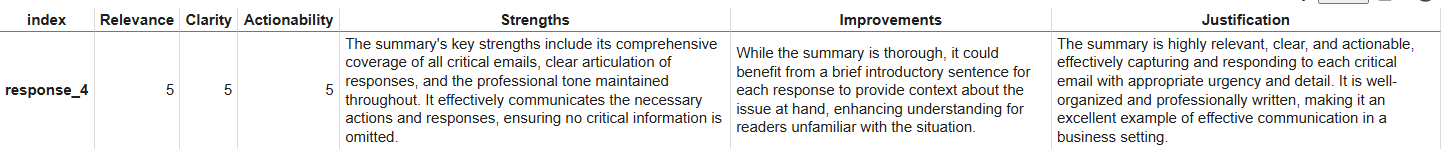

# **Task 4: Summary and Recommendation**

**Note:** Follow the instructions carefully and complete the missing sections.

In this task, you will write a **Summary and Recommendation** for the generated customer review response based on your understanding.

**Instructions:**

In this section, summarize the overall performance of the generated email summary across all tasks.

**1. Summary of Observations:**

* Briefly describe how the AI Email Secretary performed in summarizing emails.
* Highlight any patterns observed in the summaries (e.g., accuracy, level of detail, or any common errors).

**2. Evaluation Highlights:**

* Mention how the generated summaries performed on key dimensions:
  * Relevance: Did the summary capture the important points of the email?
  * Clarity: Was the summary easy to understand?
  * Actionability: Did the summary convey any next steps or actions required?

**3. Strengths:**

* List 2-3 strengths of the generated summaries (e.g., good at capturing action points, concise representation).

**4. Improvement Areas:**

* Suggest 1-2 areas where the AI Email Secretary can improve (e.g., missing certain details, inconsistent language).

**5. Final Recommendation:**

* Conclude with a recommendation on whether the current performance meets user needs or if further improvements are needed.

# **Summary:**

**1. Summary of Observations:**

* The AI email secretary had a somewhat consistent performance of summarizing emails and capturing key points. There was a bit of inconsistency between the top level summary of the inbox and the individual categorization of the emails. I think the classification program had a bit of difficulty in deciding if a email was urgent or deadline driven. As for the generate summaries, the emails were as a whole quite accurate and detailed in the information, allowing for specific information to be relayed within the summaries themsleves.

**2. Evaluation Highlights:**
  * Relevance: The summaries were able to effectively capture the core message of the emails, even going so far as to incorporate specific information to the tasks themselves. However, there are some follow up questions or statements that the summaries did fail to capture, such as requests for further follow up discussions. Interesting enough, sometimes these missing aspects are added to the next steps section instead.
  * Clarity: The summaries are very easy to understand with clear language. There are times that acronyms are used throughout, but that is most likely due to the language of the emails themselves.
  * Actionability: While the summaries themselves did not include actionable points, the Next Steps section always included a followup or actionable step that the user could take.

**3. Strengths:**
* The summary is able to quickly and consisely summarize relatively complicated emails into easily readable summaries that preserve the majority of the information in the original
* The Next Steps section gives a very clear path that the user can take to respond to the emails

**4. Improvement Areas:**
* Consistency in determining whether an email is an Urgent email or Deadline Driven
* Including followup questions and additional discussions inside the summaries in addtion to the next actions section

**5. Final Recommendation:**

* I think for the most part, the system does meet the user's need and allows for a clean and quick summary of the acionable emails for yesterday. There is a bit of inconsistency in deciding whether an email should be labeled Urgent or Deadline, but an easy fix for that would be to first categorize each email, and then create the top level summary based of the categorization. This would make it so the generative AI classifies each email only once, rather than twice which would lead to more consistency in the classification itself. There is also a bit of inconsistency of the formatting of the summaries themselves, though this should easily be fixed through a stricter formatting prompt.

### **Sample Example**

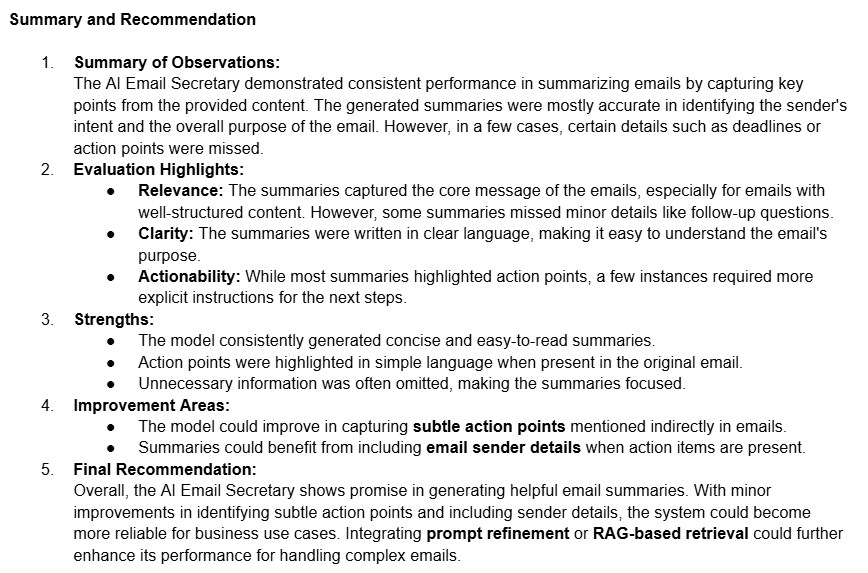

**Final Summary of Your AI Email Secretary’s Morning Report**

Every morning, you should see:

    ✔️ A structured breakdown of yesterday’s emails

    ✔️ Prioritized urgent & deadline-driven emails

    ✔️ Summarized updates & informational emails

    ✔️ AI-drafted responses to high-priority emails
